In [13]:
%pip install biopython
%pip install datasets
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Extracting Data from Dataset
Getting the data from the dataset and then converting it to a dataframe so it is easy to access

In [15]:
db = load_dataset("tattabio/modac_paralogy_bigene")
print(db)

DatasetDict({
    train: Dataset({
        features: ['ID1', 'Seq1', 'ID2', 'Seq2'],
        num_rows: 1492
    })
})


In [16]:
pos_data = db['train']

pos_data = pos_data.to_pandas()
pos_data['label'] = 1
print(pos_data)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
...      ...                                                ...     ...   
1487  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  Q1LU08   
1488  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  C7MHE5   
1489  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  C7MHQ2   
1490  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  Q2CC47   
1491  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  Q2CJ48   

                                                   Seq2  label  
0     MPSRTRLRMSDKSRNWYLIPYTAWIVLF

# Creating the extra N rows
This is so that there is negative data for the model to see as well so that it can make more accurate predictions later on

In [17]:
neg_data = pos_data.copy()
shuffle = pos_data[['ID2', 'Seq2']].sample(frac=1).reset_index(drop=True)
neg_data['ID2'] = shuffle['ID2']
neg_data['Seq2'] = shuffle['Seq2']
neg_data['label'] = 0
print(neg_data)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  G9ZXJ1   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  B9L5R7   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  D2PPY0   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  D0LJQ6   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  I3Y0C8   
...      ...                                                ...     ...   
1487  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  B0R7S4   
1488  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  D4F231   
1489  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  F2J3H1   
1490  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  A3SR06   
1491  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  Q2RWC3   

                                                   Seq2  label  
0     MRRLPLLLPTLWLVGFVALPLLVVLMLA

# Joining the positive and negative data to get a final database

In [18]:
final_db = pd.concat([pos_data, neg_data], axis=0)
print(final_db)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
...      ...                                                ...     ...   
1487  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  B0R7S4   
1488  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  D4F231   
1489  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  F2J3H1   
1490  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  A3SR06   
1491  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  Q2RWC3   

                                                   Seq2  label  
0     MPSRTRLRMSDKSRNWYLIPYTAWIVLF

# Creating the features for each sequence

In [19]:
def get_features(seq):
  # Amino acids composition
  analyzed_seq = ProteinAnalysis(seq.replace("X","").replace("Z",""))
  aa_comp = list(analyzed_seq.amino_acids_percent.values())

  # Dipeptide frequency
  aa = 'ACDEFGHIKLMNPQRSTVWY'
  dipeptides = {a+b:0 for a in aa for b in aa}

  for i in range(len(seq) - 1):
    pair = seq[i:i+2]
    if pair in dipeptides:
      dipeptides[pair] += 1

  dipeptide_freq = [count / (len(seq) - 1) for count in dipeptides.values()]

  # Physicochemical descriptors
  phys_desc = [
      analyzed_seq.gravy(),
      analyzed_seq.isoelectric_point(),
      analyzed_seq.molecular_weight(),
      analyzed_seq.aromaticity()
  ]

  return aa_comp + dipeptide_freq + phys_desc

In [20]:
f1_list = []
f2_list = []

for index, row in final_db.iterrows():
    f1 = get_features(row['Seq1'])
    f2 = get_features(row['Seq2'])

    f1_list.append(f1)
    f2_list.append(f2)


aa_names = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
dipep_names = [f"dp_{i}" for i in range(400)]
phys_names = ['gravy', 'isoelectric_point', 'mol_weight', 'aromaticity']

header = aa_names + dipep_names + phys_names

df_features1 = pd.DataFrame(f1_list, columns=[f"s1_{name}" for name in header])
df_features2 = pd.DataFrame(f2_list, columns=[f"s2_{name}" for name in header])

final_db = pd.concat([final_db.reset_index(drop=True), df_features1, df_features2], axis=1)

print(final_db)

         ID1                                               Seq1     ID2  \
0     E0I7Z3  MSDTNSIIRFERVTKRYDNGSPVLSDVSFEIERGKFYTLLGPSGCG...  E0I7Z2   
1     D9PZK5  MILNAGMLSSGGVDMEYIRLEDVWKTYRTKNVTATPLRGLNMNVDK...  D9PZK6   
2     C4LAU3  MLLAEKLQTRRQGRLFEFSLQLQPGEIGLLLGRSGSGKSTLLEMLA...  C4LAU4   
3     C4LAH6  MNAIEIHNLQCGYQEQAILQNVSFVLEERKILALLGPSGCGKTTLL...  C4LAH7   
4     C4L8Q6  MHDIEIRLCWSRSEFQLDVALQLPGQGVSALFGPSGCGKTTCLRAI...  C4L8Q7   
...      ...                                                ...     ...   
2979  Q1LU07  MSITIENVSKFFDNTQVLNNISLDINSGQMVALLGPSGSGKTTLLR...  B0R7S4   
2980  C7MHE4  MNSVDLENVTKIYSGSTPSVDDVSLTVGDGEFFTLLGPSGCGKSTT...  D4F231   
2981  C7MHQ3  MITFDDITVRFGQFTALPSLSLNIDEGEFFTLLGPSGCGKSTALRT...  F2J3H1   
2982  Q2CC48  MTELSLRGLTKRFGNHTAVDDVTLDVPDGSFICLLGPSGCGKTTLL...  A3SR06   
2983  Q2CJ49  MASVEISGLRKLYADVVALEDINLSIPTGSFYTLLGPSGCGKTTLL...  Q2RWC3   

                                                   Seq2  label       s1_A  \
0     MPSRTRLRMSDKSRNW

# Creating the Model and Hyperparameter Tuning

In [21]:
X = final_db.iloc[:, 5:]
y = final_db['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l2']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

c:\Users\advay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\advay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\advay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.001, 0.01, ...], 'logreg__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

# Checking Model Performance

In [ ]:
y_pred = grid_search.predict(X_test)
y_predprob = grid_search.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

print()

recall = recall_score(y_test, y_pred)
print("Recall: ", recall)

print()

f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)

print()

def calculate_recall_at_k(y_test, y_predprob, k=50):
    y_test = np.array(y_test)
    
    order = np.argsort(y_predprob)[::-1]
    
    y_test_sorted = y_test[order[:k]]
    
    return np.sum(y_test_sorted) / np.sum(y_test)

recall_50 = calculate_recall_at_k(y_test, y_predprob, k=50)
print("Recall@50: ", recall_50)



Accuracy:  0.18760469011725292

Recall:  0.159375

F1 score:  0.1737649063032368

Recall@50:  0.003125


# Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion")

# Plotting Comparison Graphs

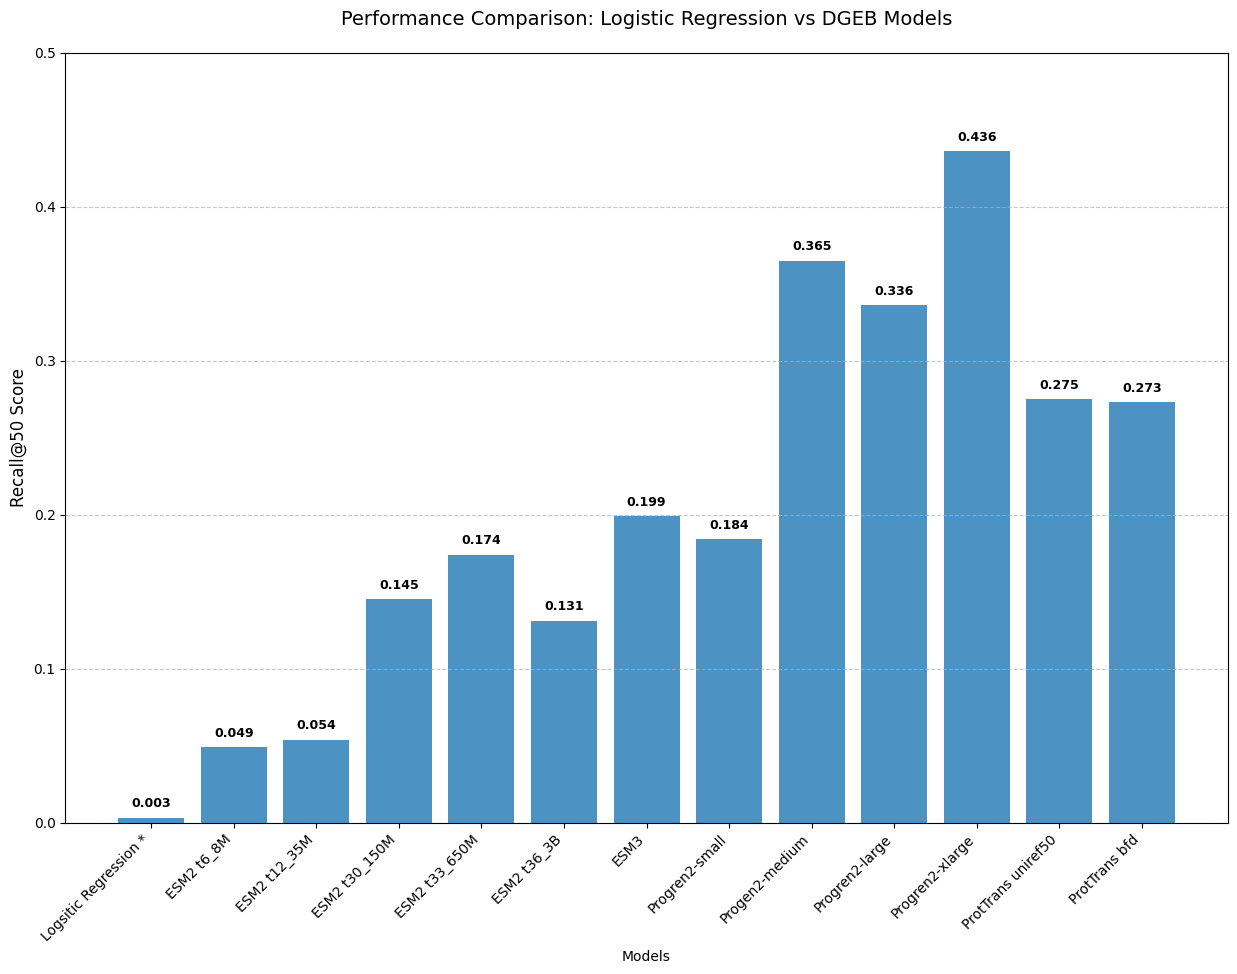

In [35]:
models = ['Logsitic Regression *', 'ESM2 t6_8M', 'ESM2 t12_35M', 'ESM2 t30_150M', 'ESM2 t33_650M', 'ESM2 t36_3B', 'ESM3', 
          'Progren2-small', 'Progen2-medium', 'Progren2-large', 'Progren2-xlarge', 'ProtTrans uniref50', 'ProtTrans bfd']
recall50_scores = [recall_50, 0.049, 0.054, 0.145, 0.174, 0.131, 0.199, 0.184, 0.365, 0.336, 0.436, 0.275, 0.273]

plt.figure(figsize=(15, 10))
bars = plt.bar(models, recall50_scores, alpha=0.8)

# Add styling
plt.xlabel("Models")
plt.ylabel("Recall@50 Score", fontsize=12)
plt.title("Performance Comparison: Logistic Regression vs DGEB Models", fontsize=14, pad=20)
plt.ylim(0, 0.50)  
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, 
             f'{yval:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# plt.tight_layout()
plt.show()

\* - Logistic Regression is a supervised model while the DGEB models are unsupervised so it is not possible to do an exact one-to-one comparison of our model to the paper